# 用邻接表实现图

In [86]:
from matplotlib.pyplot import disconnect


class Graph:
    def __init__(self, is_directed=False):
        self.is_directed = is_directed # 是否为有向图
        self.adj_list={} # 邻接表:{顶点:[邻接顶点1,邻接顶点2,邻接顶点3,...]}

    def add_vertex(self, vertex):
        """添加顶点（若不存在则初始化）"""
        if vertex not in self.adj_list:
            self.adj_list[vertex]=[]

    def add_edge(self, vertex1, vertex2):
        """添加边：v1 -> v2"""
        # 确保两个顶点都存在
        self.add_vertex(vertex1)
        self.add_vertex(vertex2)

        # 向vertex1的邻接表添加vertex2
        if vertex2 not in self.adj_list[vertex1]:
            self.adj_list[vertex1].append(vertex2)

        # 无向图：反向边也添加
        if not self.is_directed and vertex1 not in self.adj_list[vertex2]:
            self.adj_list[vertex2].append(vertex1)

        def remove_edge(self, vertex1, vertex2):
            """删除边：v1 -> v2（无向图同时删除v2 -> v1）"""
            if vertex1 in self.adj_list and vertex2 in self.adj_list[vertex1]:
                self.adj_list[vertex1].remove(vertex2)
            if not self.is_directed and vertex2 in self.adj_list and vertex1 in self.adj_list[vertex2]:
                self.adj_list[vertex2].remove(vertex1)

    def remove_vertex(self, vertex):
        """删除顶点（同时删除所有关联的边）"""
        if vertex not in self.adj_list:
            return
        # 1. 删除其他顶点的邻接表
        del self.adj_list[vertex]
        # 2. 删除其他顶点中指向改顶点的边
        for v in self.adj_list:
            if vertex in self.adj_list[v]:
                self.adj_list[v].remove(vertex)

    def __str__(self):
        """打印邻接表"""
        result = []
        for vertex in self.adj_list:
            result.append(f'{vertex}: {self.adj_list[vertex]}')
        return '\n'.join(result)

## 无向图
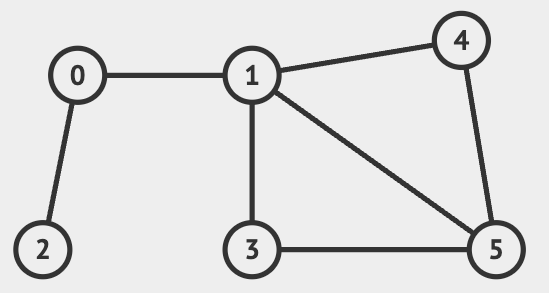

In [87]:
undirected_graph = Graph(is_directed=False)
undirected_graph.add_edge("0", "1")
undirected_graph.add_edge("0", "2")
undirected_graph.add_edge("1", "3")
undirected_graph.add_edge("1", "4")
undirected_graph.add_edge("1", "5")
undirected_graph.add_edge("3", "5")
undirected_graph.add_edge("4", "5")

print(undirected_graph)

0: ['1', '2']
1: ['0', '3', '4', '5']
2: ['0']
3: ['1', '5']
4: ['1', '5']
5: ['1', '3', '4']


## 有向图
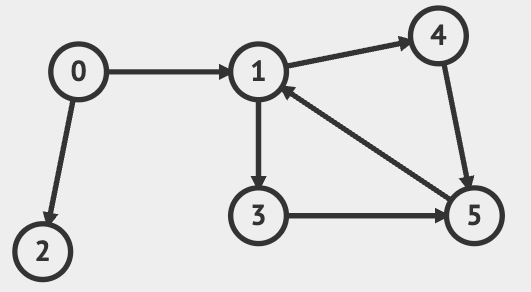

In [88]:
directed_graph = Graph(is_directed=True)
directed_graph.add_edge("0", "1")
directed_graph.add_edge("0", "2")
directed_graph.add_edge("1", "3")
directed_graph.add_edge("1", "4")
directed_graph.add_edge("3", "5")
directed_graph.add_edge("4", "5")
directed_graph.add_edge("5", "1")

print(directed_graph)

0: ['1', '2']
1: ['3', '4']
2: []
3: ['5']
4: ['5']
5: ['1']


## 深度优先遍历｜DFS
- 先深后广，从起始顶点出发，优先访问邻接的未访问顶点，直到无法深入再回溯
- 实现方式：递归+迭代

In [89]:
class DFS:
    def __init__(self, graph):
        self.graph = graph

    def dfs_recursive(self, satrt_vertex, visited=None):
        """DFS递归版"""
        if visited is None: # 初始化已访问集合，避免重复访问，解决环的问题
            visited = set()
        visited.add(satrt_vertex) # 标记当前顶点已访问
        result = [satrt_vertex] # 存储遍历结果

        for neighbor in self.graph.adj_list[satrt_vertex]: # 遍历当前顶点的所有邻接顶点
            if neighbor not in visited:
                result.extend(self.dfs_recursive(neighbor, visited))
        return result

    def dfs_iterative(self,start_vertex):
        """DFS迭代版，用栈实现"""
        if start_vertex not in self.graph.adj_list:
            return []
        visited = set() # 记录已访问节点
        stack = [start_vertex] # 栈存储待访问顶点
        result = []

        while stack:
            vertex = stack.pop()
            if vertex not in visited:
                visited.add(vertex)
                result.append(vertex)
                # 逆序添加邻接顶点（保证遍历顺序和递归版本一致）
                for neighbor in reversed(self.graph.adj_list[vertex]):
                    if neighbor not in visited:
                        stack.append(neighbor)
        return result

In [90]:
undfs = DFS(undirected_graph)
dfs = DFS(directed_graph)

dfs.dfs_recursive("0"),dfs.dfs_iterative("0")

(['0', '1', '3', '5', '4', '2'], ['0', '1', '3', '5', '4', '2'])

## 广度优先遍历｜BFS
- 核心逻辑：先广后深，从起始顶点出发，先访问所有邻接顶点，再逐层访问下一级顶点。
- 迭代（使用队列，FIFO特性保证“广度”）

In [91]:
from collections import deque # 高效的双端队列

class BFS:
    def __init__(self, graph):
        self.graph = graph

    def bfs(self, start_vertex):
        """BFS遍历，队列实现"""
        if start_vertex not in self.graph.adj_list:
            return []
        visited = set() # 初始化已访问顶点
        queue = deque(start_vertex) # 队列存储待访问顶点
        visited.add(start_vertex)
        result = [start_vertex]
        while queue:
            vertex = queue.popleft() # 弹出队首顶点
            for neighbor in self.graph.adj_list[vertex]: # 遍历当前顶点的所有邻接顶点
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
                    result.append(neighbor)
        return result

In [92]:
unbfs = BFS(undirected_graph)
bfs = BFS(directed_graph)

unbfs.bfs("0"),bfs.bfs("0")

(['0', '1', '2', '3', '4', '5'], ['0', '1', '2', '3', '4', '5'])

## 非连通图的遍历

In [102]:
def dfs_full(self):
    """遍历全图（处理非连通图）"""
    visited = set()
    result = []
    for vertex in self.graph.adj_list:
        if vertex not in visited:
            result += self.dfs_recursive(vertex, visited)
    return result

def bfs_full(self):
    """遍历全图（处理非连通图）"""
    visited = set()
    result = []
    for vertex in self.graph.adj_list:
        if vertex not in visited:
            # 单独处理当前连通分量的BFS
            queue = deque([vertex])
            visited.add(vertex)
            result.append(vertex)
            while queue:
                v = queue.popleft()
                for neighbor in self.graph.adj_list[v]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
                        result.append(neighbor)
    return result

# 让上面两个方法绑定进上上面的两个类里面
DFS.dfs_full = dfs_full
BFS.bfs_full = bfs_full

In [103]:
undirected_graph.add_edge("6", "7")
directed_graph.add_edge("6", "7")

undfs.dfs_full(),dfs.dfs_full(),unbfs.bfs_full(),bfs.bfs_full()

(['0', '1', '3', '5', '4', '2', '6', '7'],
 ['0', '1', '3', '5', '4', '2', '6', '7'],
 ['0', '1', '2', '3', '4', '5', '6', '7'],
 ['0', '1', '2', '3', '4', '5', '6', '7'])